In [1]:
CSV_PATH = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/mass_merger/chirp_mass_ft_FIX_snr_5_50_59-63s_d64_s64_l4/plots/param_est_results.csv'

In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})

df = pd.read_csv(CSV_PATH)
print(f'{len(df):,} events  |  columns: {list(df.columns)}')

# ── parse columns automatically ───────────────────────────────────────────────
vars_      = [c.replace('_true', '') for c in df.columns if c.endswith('_true')]
true_d     = {v: df[f'{v}_true'].values    for v in vars_}
pred_d     = {v: df[f'{v}_pred'].values    for v in vars_}
residual_d = {v: df[f'{v}_residual'].values for v in vars_}

sigma_d  = {c.removeprefix('sigma_').removesuffix('_pred'): df[c].values
            for c in df.columns if c.startswith('sigma_') and c.endswith('_pred')}
zscore_d = {c.removesuffix('_zscore'): df[c].values
            for c in df.columns if c.endswith('_zscore')}

snr = df['snr'].values if 'snr' in df.columns else None

# ── display helpers ───────────────────────────────────────────────────────────
VAR_LABELS = {
    'chirp_mass': r'$\mathcal{M}_c\,[M_\odot]$',
    'mass_ratio': r'$q$',
}
BINS = {
    'chirp_mass': np.linspace(0.5, 3.0, 51),
    'mass_ratio': np.linspace(0.0, 1.0, 51),
}

def label(v):
    return VAR_LABELS.get(v, v)

def bins_for(v, data):
    if v in BINS:
        b = BINS[v]
        if data.max() < b[0] or data.min() > b[-1]:
            return np.linspace(data.min(), data.max(), len(b))
        return b
    return np.linspace(data.min(), data.max(), 51)

def hist_outline(ax, data, bins, **kw):
    c, e = np.histogram(data, bins=bins)
    ax.stairs(c, e, **kw)

n = len(vars_)
df.head(3)

100,000 events  |  columns: ['chirp_mass_true', 'mass_ratio_true', 'chirp_mass_pred', 'mass_ratio_pred', 'sigma_chirp_mass_pred', 'sigma_mass_ratio_pred', 'chirp_mass_residual', 'mass_ratio_residual', 'chirp_mass_zscore', 'mass_ratio_zscore', 'snr']


,chirp_mass_true,mass_ratio_true,chirp_mass_pred,mass_ratio_pred,sigma_chirp_mass_pred,sigma_mass_ratio_pred,chirp_mass_residual,mass_ratio_residual,chirp_mass_zscore,mass_ratio_zscore,snr
0,1.216118,0.605457,1.190363,0.767031,0.021460,0.135712,-0.025755,0.161574,-1.200157,1.190566,22.053020
1,1.665317,0.797975,1.721541,0.812805,0.014552,0.094655,0.056224,0.014830,3.863744,0.156677,41.950680
2,1.506810,0.896340,1.522433,0.736859,0.013121,0.134220,0.015623,-0.159482,1.190641,-1.188212,35.749702


## True vs Predicted Histograms

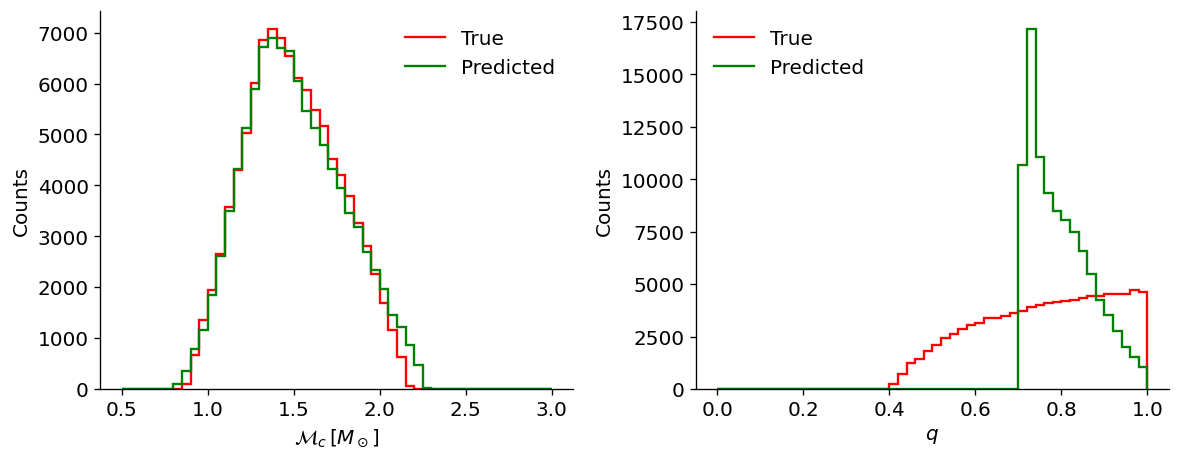

In [3]:
ncols = min(n, 4); nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
for ax, v in zip(axes.flat, vars_):
    bins = bins_for(v, true_d[v])
    hist_outline(ax, true_d[v], bins, color='red',   lw=1.4, label='True')
    hist_outline(ax, pred_d[v], bins, color='green', lw=1.4, label='Predicted')
    ax.set_xlabel(label(v)); ax.set_ylabel('Counts')
    ax.legend(frameon=False)
for ax in axes.flat[n:]: ax.set_visible(False)
fig.tight_layout()
plt.show()

## Predicted vs True (Mean ± 68% Band)

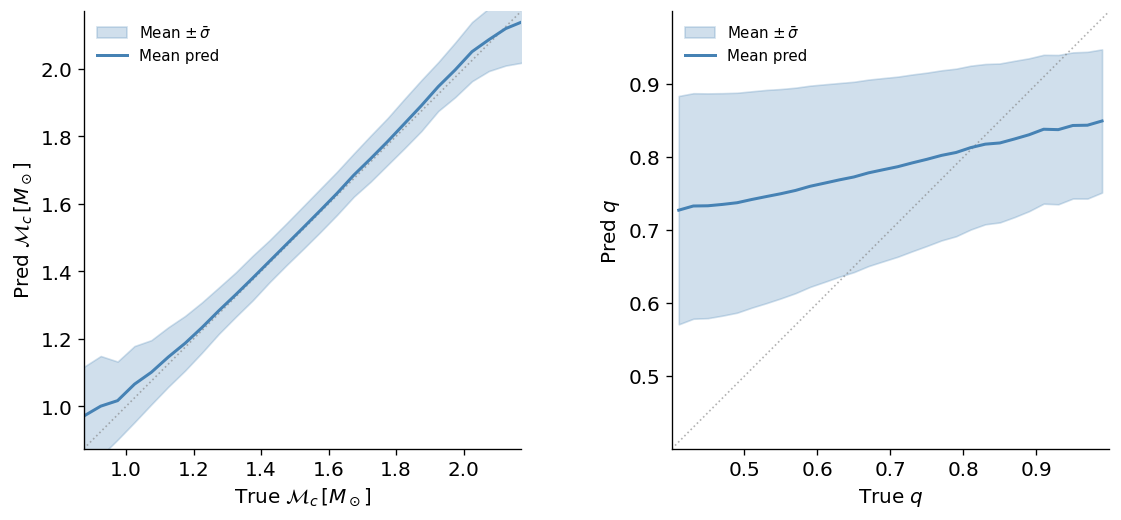

In [10]:
ncols = min(n, 4); nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows), squeeze=False)
for ax, v in zip(axes.flat, vars_):
    edges   = bins_for(v, true_d[v])
    centers = 0.5 * (edges[:-1] + edges[1:])
    tr, pr  = true_d[v], pred_d[v]
    sig     = sigma_d.get(v)

    mean_p    = np.full(len(centers), np.nan)
    mean_sig  = np.full(len(centers), np.nan)

    for i, (lo, hi) in enumerate(zip(edges[:-1], edges[1:])):
        m = (tr >= lo) & (tr < hi)
        if m.sum() < 2: continue
        mean_p[i]   = np.mean(pr[m])
        if sig is not None:
            mean_sig[i] = np.mean(sig[m])

    valid  = ~np.isnan(mean_p)
    lo_d, hi_d = float(tr.min()), float(tr.max())
    ax.plot([lo_d, hi_d], [lo_d, hi_d], color='gray', lw=1.0, ls=':', alpha=0.6)

    if sig is not None and not np.all(np.isnan(mean_sig)):
        ax.fill_between(centers[valid],
                        mean_p[valid] - mean_sig[valid],
                        mean_p[valid] + mean_sig[valid],
                        alpha=0.25, color='steelblue', label=r'Mean $\pm\,\bar{\sigma}$')
    ax.plot(centers[valid], mean_p[valid], color='steelblue', lw=1.8, label='Mean pred')

    ax.set_xlim(lo_d, hi_d); ax.set_ylim(lo_d, hi_d); ax.set_aspect('equal')
    ax.set_xlabel('True ' + label(v)); ax.set_ylabel('Pred ' + label(v))
    ax.legend(frameon=False, fontsize=9)
for ax in axes.flat[n:]: ax.set_visible(False)
fig.tight_layout()
plt.show()

## Predicted Uncertainty (σ) Histograms

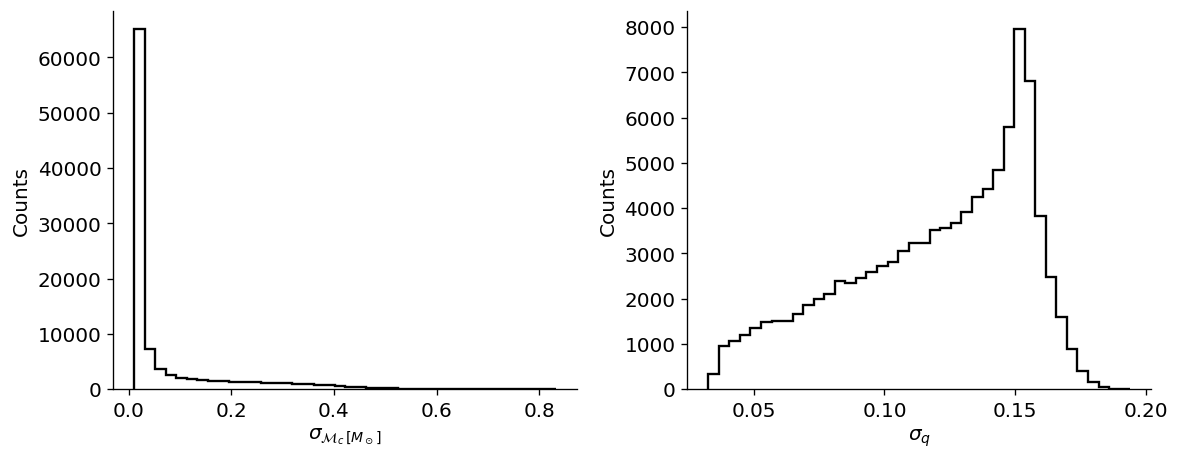

In [5]:
if sigma_d:
    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        if v in sigma_d:
            hist_outline(ax, sigma_d[v], bins=40, color='black', lw=1.4)
            lbl = label(v).strip('$')
            ax.set_xlabel(rf'$\sigma_{{{lbl}}}$'); ax.set_ylabel('Counts')
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No sigma columns in CSV.')

## Z-Score Histograms
Ideal: unit Gaussian centred at 0.

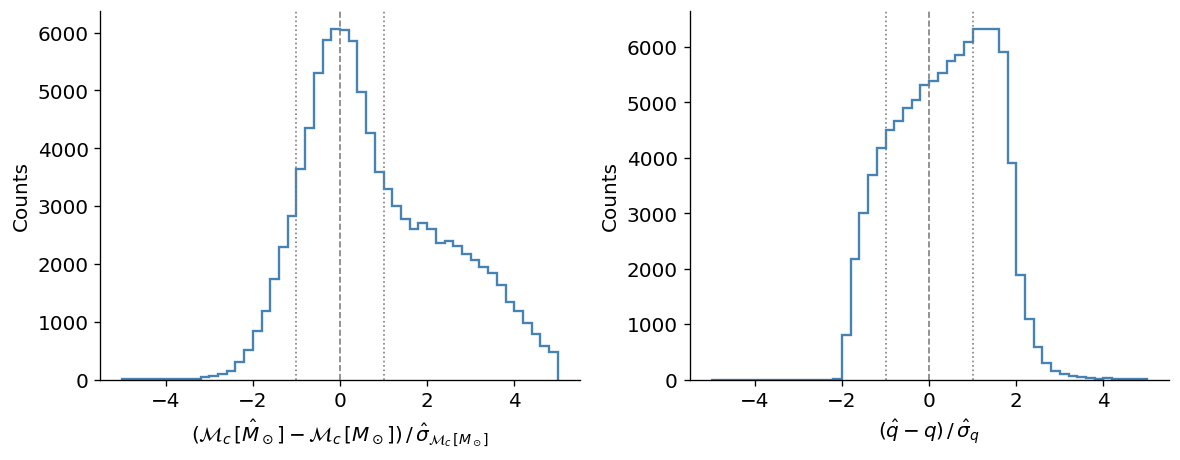

In [6]:
if zscore_d:
    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        if v in zscore_d:
            hist_outline(ax, zscore_d[v], bins=np.linspace(-5, 5, 51),
                         color='steelblue', lw=1.4)
            ax.axvline( 0, color='gray', ls='--',     lw=1.0)
            ax.axvline( 1, color='gray', ls='dotted', lw=1.0)
            ax.axvline(-1, color='gray', ls='dotted', lw=1.0)
            lbl = label(v).strip('$')
            ax.set_xlabel(rf'$(\hat{{{lbl}}} - {lbl})\,/\,\hat{{\sigma}}_{{{lbl}}}$')
            ax.set_ylabel('Counts')
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No z-score columns in CSV.')

## SNR-Binned Residuals (Median ± 68%)

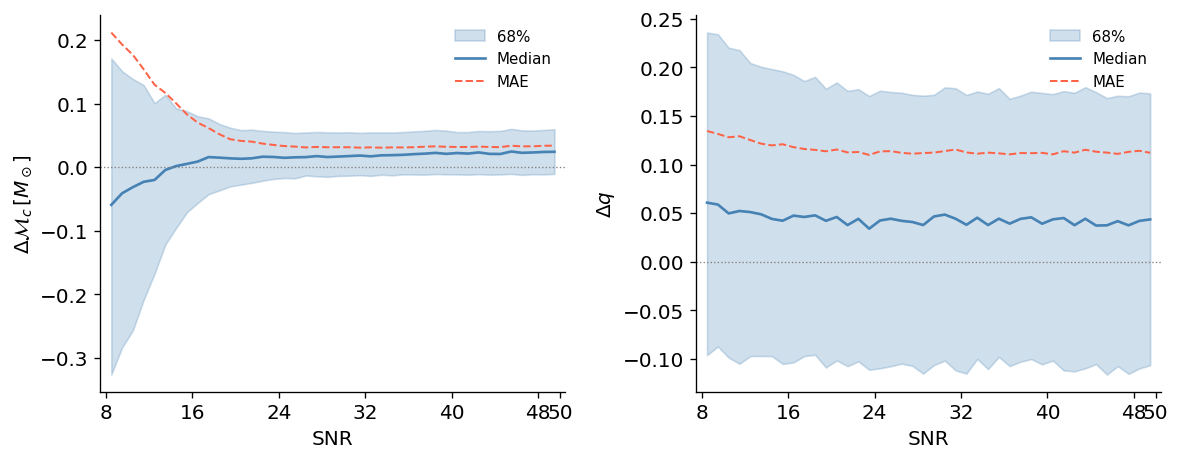

In [7]:
if snr is not None:
    snr_bins    = np.arange(int(np.floor(snr.min())), int(np.ceil(snr.max())) + 1, dtype=float)
    snr_centers = 0.5 * (snr_bins[:-1] + snr_bins[1:])
    snr_a, snr_b = int(snr_bins[0]), int(snr_bins[-1])
    step  = max(2, (snr_b - snr_a) // 5)
    ticks = sorted(set(range(snr_a, snr_b + 1, step)) | {snr_a, snr_b})

    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        res = residual_d[v]
        med = np.full(len(snr_centers), np.nan)
        q16 = np.full(len(snr_centers), np.nan)
        q84 = np.full(len(snr_centers), np.nan)
        mae = np.full(len(snr_centers), np.nan)
        for i, (lo, hi) in enumerate(zip(snr_bins[:-1], snr_bins[1:])):
            m = (snr >= lo) & (snr < hi)
            if m.sum() < 2: continue
            r = res[m]
            med[i] = np.median(r); q16[i] = np.percentile(r, 16)
            q84[i] = np.percentile(r, 84); mae[i] = np.mean(np.abs(r))
        valid = ~np.isnan(med); sc = snr_centers[valid]
        ax.fill_between(sc, q16[valid], q84[valid], alpha=0.25, color='steelblue', label='68%')
        ax.plot(sc, med[valid], color='steelblue', lw=1.6, label='Median')
        ax.plot(sc, mae[valid], color='tomato',    lw=1.2, ls='--', label='MAE')
        ax.axhline(0, color='gray', lw=0.8, ls=':')
        ax.set_xlabel('SNR'); ax.set_ylabel(r'$\Delta$' + label(v))
        ax.legend(frameon=False, fontsize=9)
        ax.set_xticks(ticks); ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No SNR column in CSV.')

## SNR vs Fraction Within Relative-Error Cutoff
Cutoffs: 1%, 5%, 10%, 50%  (|Δ/true| < cutoff).

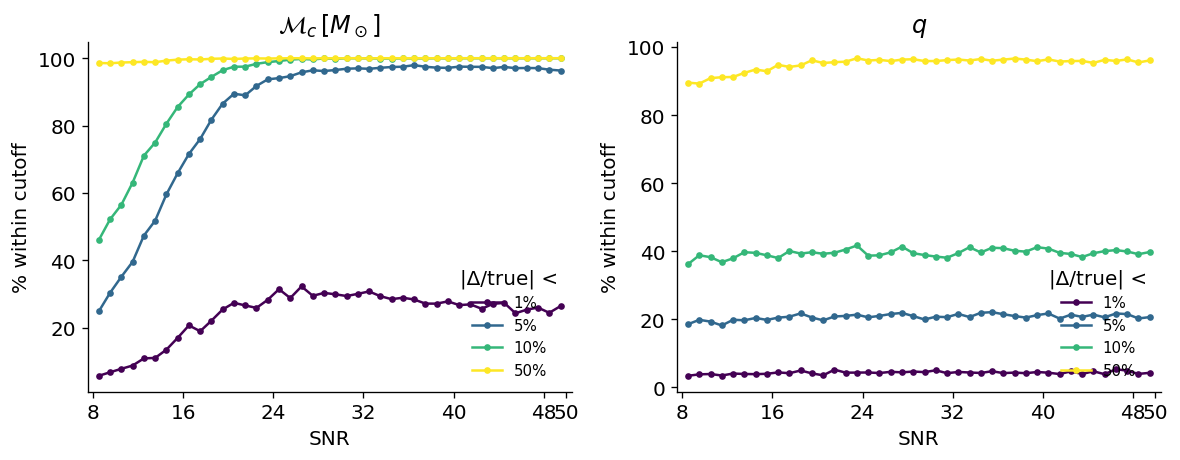

In [8]:
if snr is not None:
    CUTS = [0.01, 0.05, 0.10, 0.50]
    CLRS = [plt.cm.viridis(j / (len(CUTS) - 1)) for j in range(len(CUTS))]

    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        res     = residual_d[v]
        denom   = np.where(np.abs(true_d[v]) > 1e-8, np.abs(true_d[v]), 1.0)
        rel_err = np.abs(res / denom)
        for cut, clr in zip(CUTS, CLRS):
            frac = np.full(len(snr_centers), np.nan)
            for i, (lo, hi) in enumerate(zip(snr_bins[:-1], snr_bins[1:])):
                m = (snr >= lo) & (snr < hi)
                if m.sum() > 0:
                    frac[i] = 100.0 * (rel_err[m] < cut).mean()
            valid = ~np.isnan(frac)
            ax.plot(snr_centers[valid], frac[valid], marker='o', ms=3,
                    color=clr, label=f'{int(cut*100)}%')
        ax.set_xlabel('SNR'); ax.set_ylabel('% within cutoff')
        ax.set_title(label(v))
        ax.legend(frameon=False, fontsize=9, title='|Δ/true| <', loc='lower right')
        ax.set_xticks(ticks); ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No SNR column in CSV.')

## Relative Error Violin vs SNR

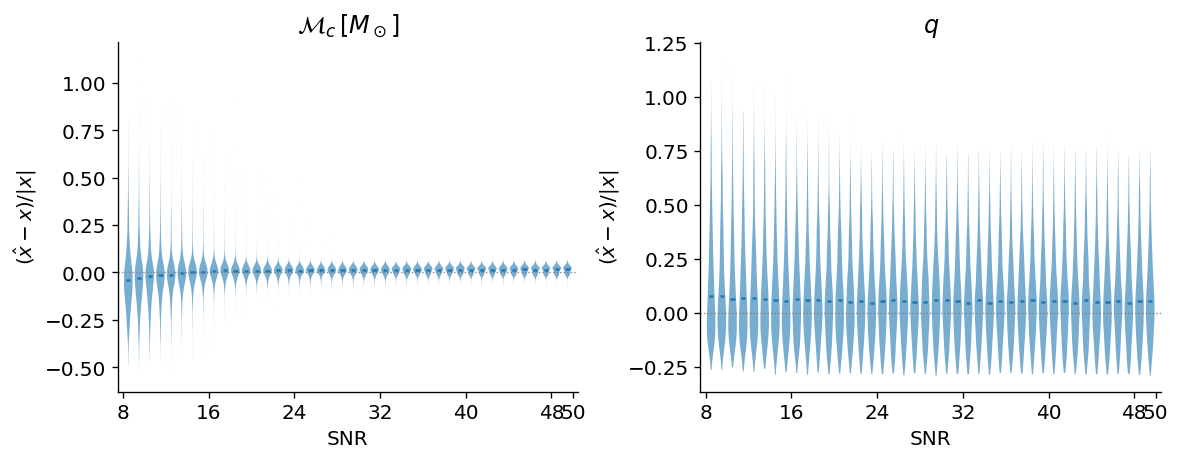

In [9]:
if snr is not None:
    ncols = min(n, 4); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
    for ax, v in zip(axes.flat, vars_):
        res     = residual_d[v]
        denom   = np.where(np.abs(true_d[v]) > 1e-8, np.abs(true_d[v]), 1.0)
        rel_err = res / denom
        groups  = [rel_err[(snr >= snr_bins[i]) & (snr < snr_bins[i+1])]
                   for i in range(len(snr_bins)-1)]
        nonempty = [i for i, g in enumerate(groups) if len(g) > 1]
        if nonempty:
            vp = ax.violinplot([groups[i] for i in nonempty],
                               positions=snr_centers[nonempty], widths=0.8,
                               showmedians=True, showextrema=False)
            for body in vp['bodies']: body.set_alpha(0.6)
        ax.axhline(0, color='gray', lw=0.8, ls=':')
        ax.set_xlabel('SNR'); ax.set_ylabel(r'$(\hat{x}-x)/|x|$')
        ax.set_title(label(v))
        ax.set_xticks(ticks); ax.set_xlim(snr_a - 0.5, snr_b + 0.5)
    for ax in axes.flat[n:]: ax.set_visible(False)
    fig.tight_layout()
    plt.show()
else:
    print('No SNR column in CSV.')

## Background CSV Path

In [ ]:
BKG_CSV_PATH = '/n/holystore01/LABS/iaifi_lab/Lab/kyoon/BNSReg/00_AI4GW_TALK/ZZ_misc_outputs/00_AI4GW_TALK/mass_merger_bkg/plots/param_est_results.csv'
df_bkg = pd.read_csv(BKG_CSV_PATH)
print(f'{len(df_bkg):,} background events  |  columns: {list(df_bkg.columns)}')
sigma_bkg = {c.removeprefix('sigma_').removesuffix('_pred'): df_bkg[c].values
             for c in df_bkg.columns if c.startswith('sigma_') and c.endswith('_pred')}


## σ Chirp Mass: Signal vs Background

In [ ]:
v = 'chirp_mass'
if v in sigma_d and v in sigma_bkg:
    sig_sigma = sigma_d[v]
    bkg_sigma = sigma_bkg[v]
    xmax = np.percentile(np.concatenate([sig_sigma, bkg_sigma]), 99)
    bins = np.linspace(0, xmax, 60)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(sig_sigma, bins=bins, density=True,
            alpha=0.55, color='steelblue', label='Signal')
    ax.hist(bkg_sigma, bins=bins, density=True,
            alpha=0.55, color='tomato',    label='Background')
    ax.set_xlabel(r'$\hat{\sigma}_{\mathcal{M}_c}$')
    ax.set_ylabel('Density')
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()
else:
    print('sigma_chirp_mass_pred not found in one of the CSVs.')


## ROC Curve: σ Chirp Mass as Discriminant
Signal: events below threshold (low uncertainty = confident = signal-like).  
Lower σ → classified as signal.

In [ ]:
from sklearn.metrics import roc_curve, auc

v = 'chirp_mass'
if v in sigma_d and v in sigma_bkg:
    scores_sig = sigma_d[v]      # signal: want low sigma
    scores_bkg = sigma_bkg[v]    # background

    y_true   = np.concatenate([np.ones(len(scores_sig)), np.zeros(len(scores_bkg))])
    # negate so that lower sigma = higher score = more signal-like
    y_score  = np.concatenate([-scores_sig, -scores_bkg])

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc     = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(5.5, 5))
    ax.plot(fpr, tpr, color='steelblue', lw=2.0,
            label=rf'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], color='gray', lw=1.0, ls='--', alpha=0.6)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(r'ROC: cut on $\hat{\sigma}_{\mathcal{M}_c}$')
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    print(f'AUC = {roc_auc:.4f}')
else:
    print('sigma_chirp_mass_pred not found in one of the CSVs.')
